In [2]:
# Imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load dataframe
df = pd.read_csv('salary_lpa.csv')
print(df.head())

   Experience_years  Salary_lpa
0               0.5         3.0
1               1.0         3.5
2               2.0         4.5
3               3.0         5.2
4               4.0         6.0


In [4]:
# Feature and Target selection
x = df[['Experience_years']]
y = df['Salary_lpa']

In [5]:
# Data partitioning
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [6]:
# Model training
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# Printing slope and intercept(not necessary)
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Slope: 0.7623129251700681
Intercept: 2.8900680272108836


In [8]:
# Model testing
y_pred = model.predict(x_test)
print("Actual vs predicted")
for actual, pred in zip(y_test, y_pred):
    print(f"Actual: {actual}, Predicted: {pred}")

Actual vs predicted
Actual: 6.8, Predicted: 6.701632653061225
Actual: 3.0, Predicted: 3.2712244897959177
Actual: 10.5, Predicted: 10.513197278911566


In [9]:
# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("R2 Score: ", r2_score)

Mean Absolute Error:  0.1275963718820862
R2 Score:  0.9970343792256637


In [10]:
# predicting on new data
new_experience_year = 9
new_experience_year_df = pd.DataFrame({'Experience_years': [new_experience_year]})
new_salary_pred = model.predict(new_experience_year_df)
print(f"New Salary Prediction for {new_experience_year} years : {round(new_salary_pred[0], 4)}")

New Salary Prediction for 9 years : 9.7509


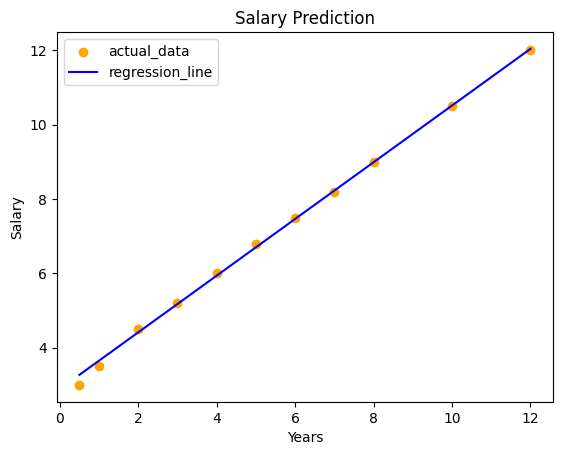

In [11]:
# Visualization
plt.scatter(x, y, color='orange', label='actual_data')
plt.plot(x, model.predict(x), color='blue', label='regression_line')
plt.title('Salary Prediction')
plt.xlabel('Years')
plt.ylabel('Salary')
plt.legend()
plt.show()